In [17]:
# Some data-handling functions to download/import.

# from https://github.com/yandexdataschool/mlhep2018/blob/master/day2-Tue/seminar-03-keras-cnn/seminar_tf_keras.ipynb
"""I load some cifar"""

import numpy as np
from sklearn.model_selection import train_test_split
import os, sys
if sys.version_info[0] == 2:
    from urllib import urlretrieve
    import cPickle as pickle

else:
    from urllib.request import urlretrieve
    import pickle

def unpickle(file):
    fo = open(file, 'rb')
    if sys.version_info[0] == 2:
        dict = pickle.load(fo)
    else:
        dict = pickle.load(fo,encoding='latin1')

    fo.close()
    return dict




def download_cifar10(path,
                     url='https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz',
                     tarname='cifar-10-python.tar.gz',):
    import tarfile
    if not os.path.exists(path):
        os.mkdir(path)



    urlretrieve(url, os.path.join(path,tarname))
    tfile = tarfile.open(os.path.join(path,tarname))
    tfile.extractall(path=path)


def load_cifar10(data_path=".",channels_last=False,test_size=0.2,random_state=1337):

    test_path = os.path.join(data_path,"cifar-10-batches-py/test_batch")
    train_paths = [os.path.join(data_path,"cifar-10-batches-py/data_batch_%i"%i) for i in range(1,6)]

    if not os.path.exists(test_path) or not all(list(map(os.path.exists, train_paths))):
        print ("Dataset not found. Downloading...")
        download_cifar10(data_path)

    train_batches = list(map(unpickle,train_paths))
    test_batch = unpickle(test_path)

    X = np.concatenate([batch["data"] for batch in train_batches]).reshape([-1,3,32,32]).astype('float32')/255
    y = np.concatenate([batch["labels"] for batch in train_batches]).astype('int32')
    X_train,X_val,y_train,y_val = train_test_split(X,y,
                                                   test_size=test_size,
                                                   random_state=random_state)

    X_test = test_batch["data"].reshape([-1,3,32,32]).astype('float32')/255
    y_test = np.array(test_batch["labels"]).astype('int32')

    if channels_last:
        #convert from [batch,3,H,W] to [batch,H,W,3]
        #WARNING! Make this is only necessary for tensorflow-style dim order
        #If you use theano-style dimensions in keras config, skip this cell
        X_train = X_train.transpose([0,2,3,1])
        X_val   = X_val.transpose([0,2,3,1])
        X_test  = X_test.transpose([0,2,3,1])


    return X_train,y_train,X_val,y_val,X_test,y_test

In [18]:
import tensorflow as tf
#gpu_options = tf.GPUOptions(allow_growth=True, per_process_gpu_memory_fraction=0.1) # restricts GPU load for multi-user nodes

import tensorflow.keras as keras
from keras import backend as K
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
print(tf.__version__)
print(keras.__version__)

2.19.0
3.10.0


In [19]:
# Load the data samples

x_train,y_train,x_val,y_val,x_test,y_test = load_cifar10("cifar_data",channels_last=True)

NUM_CLASSES = 10
cifar10_classes = ["airplane", "automobile", "bird", "cat", "deer",
                   "dog", "frog", "horse", "ship", "truck"]

print("Train samples:", x_train.shape, y_train.shape)
print("Test samples:", x_test.shape, y_test.shape)
print("Val samples:", x_val.shape, y_val.shape)

Train samples: (40000, 32, 32, 3) (40000,)
Test samples: (10000, 32, 32, 3) (10000,)
Val samples: (10000, 32, 32, 3) (10000,)


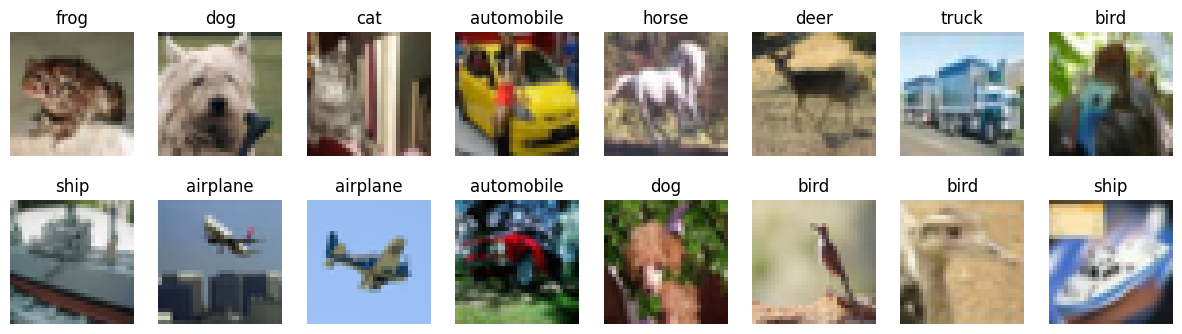

In [20]:
# show some random images from train, and their labels

cols = 8
rows = 2
fig = plt.figure(figsize=(2 * cols - 1, 2.5 * rows - 1))
for i in range(cols):
    for j in range(rows):
        random_index = np.random.randint(0, len(y_train))
        ax = fig.add_subplot(rows, cols, i * rows + j + 1)
        ax.grid('off')
        ax.axis('off')
        ax.imshow(x_train[random_index, :])
        ax.set_title(cifar10_classes[y_train[random_index]])
plt.show()

In [21]:
# normalize inputs
# convert class labels to one-hot encoded, should have shape (?, NUM_CLASSES)
# x_train = x_train.astype(np.float64) - 0.5

y_train = keras.utils.to_categorical(y_train, num_classes=10)

y_val = keras.utils.to_categorical(y_val, num_classes=10)

y_test = keras.utils.to_categorical(y_test, num_classes=10)

In [22]:
# import necessary building blocks
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Activation, Dropout, BatchNormalization, Input
from keras.layers import LeakyReLU

In [23]:
def make_model():

    model = Sequential()

    #input layer for CIFAR images (32x32 RGB)
    model.add(Input(shape=(32,32,3)))

    #simple data augmentation to increase variation in the training data
    model.add(keras.layers.RandomFlip("horizontal"))

    model.add(Conv2D(64,(3,3),padding="same",activation="relu"))
    model.add(BatchNormalization())
    model.add(Conv2D(64,(3,3),padding="same",activation="relu"))
    model.add(BatchNormalization())

    #pooling reduces the image size so the model focuses on relevant features
    model.add(MaxPooling2D((2,2)))
    model.add(Dropout(0.15))

    #deeper convolution layers detect more complex patterns
    model.add(Conv2D(128,(4,4),padding="same",activation="relu"))
    model.add(BatchNormalization())
    model.add(Conv2D(128,(4,4),padding="same",activation="relu"))

    model.add(MaxPooling2D((2,2)))
    model.add(Dropout(0.15))

    model.add(Conv2D(128,(4,4),padding="same",activation="relu"))
    model.add(BatchNormalization())
    model.add(Conv2D(128,(6,6),padding="same",activation="relu"))

    #last pooling before classification layers
    model.add(MaxPooling2D((2,2)))

    #flatten converts the feature maps into a vector
    model.add(Flatten())

    #dense layers combine extracted features for classification
    model.add(Dense(128,activation="relu"))
    model.add(Dropout(0.55))
    model.add(Dense(64,activation="relu"))
    model.add(Dropout(0.45))

    #final layer outputs probabilities for the 10 classes
    model.add(Dense(10,activation="softmax"))

    return model


print(x_train.shape) #check that images are 32x32 RGB
model = make_model()
model.summary()

(40000, 32, 32, 3)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_1 (RandomFlip)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 128)    │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 128)    │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 8, 8, 128)      │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 128)      │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,557,130 (5.94 MB)

 Trainable params: 1,556,362 (5.94 MB)

 Non-trainable params: 768 (3.00 KB)


The code above represents my final implementation of a Convolutional Neural Network designed to classify CIFAR-10 images.

The model first defines the input shape with Input(shape=(32,32,3)), meaning that each training sample is a 32×32 RGB image. A RandomFlip("horizontal") layer is then used as data augmentation to increase the variability of the training dataset.

The core of the network consists of three convolutional blocks. Each block contains Conv2D layers that apply multiple filters to detect visual patterns such as edges, textures, and simple shapes in the image. BatchNormalization() is used after some convolution layers to normalize the activations so that very large values do not dominate the training process and the model can learn more efficiently.

MaxPooling2D((2,2)) layers reduce the spatial size of the feature maps by selecting the strongest activation within small pixel regions. This helps the model focus on the most relevant features while also reducing computational complexity. Dropout layers are added to reduce overfitting.

After the convolutional part of the network, Flatten() converts the feature maps into a one-dimensional vector. This vector is processed by two dense layers (Dense(128) and Dense(64)), which learn combinations of the detected features in order to distinguish between the different object classes.

Finally, Dense(10, activation="softmax") outputs a probability distribution over the ten CIFAR-10 classes, where all probabilities sum to 1 and the highest value determines the predicted class.

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 32s 72ms/step - accuracy: 0.1804 - loss: 2.2764 - val_accuracy: 0.1708 - val_loss: 2.2358 - learning_rate: 5.0000e-04
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 46ms/step - accuracy: 0.3030 - loss: 1.9297 - val_accuracy: 0.4636 - val_loss: 1.5772 - learning_rate: 5.0000e-04
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 48ms/step - accuracy: 0.3789 - loss: 1.7192 - val_accuracy: 0.5846 - val_loss: 1.2854 - learning_rate: 5.0000e-04
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 48ms/step - accuracy: 0.4454 - loss: 1.5352 - val_accuracy: 0.5941 - val_loss: 1.1836 - learning_rate: 5.0000e-04
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 49ms/step - accuracy: 0.5171 - loss: 1.3868 - val_accuracy: 0.6565 - val_loss: 1.0282 - learning_rate: 5.0000e-04
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 51ms/step - accuracy: 0.5756 - loss: 1.2412 - val_accuracy: 0.6908 - val_loss: 0.9183 - learning_rate: 5.0000e-04
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 5

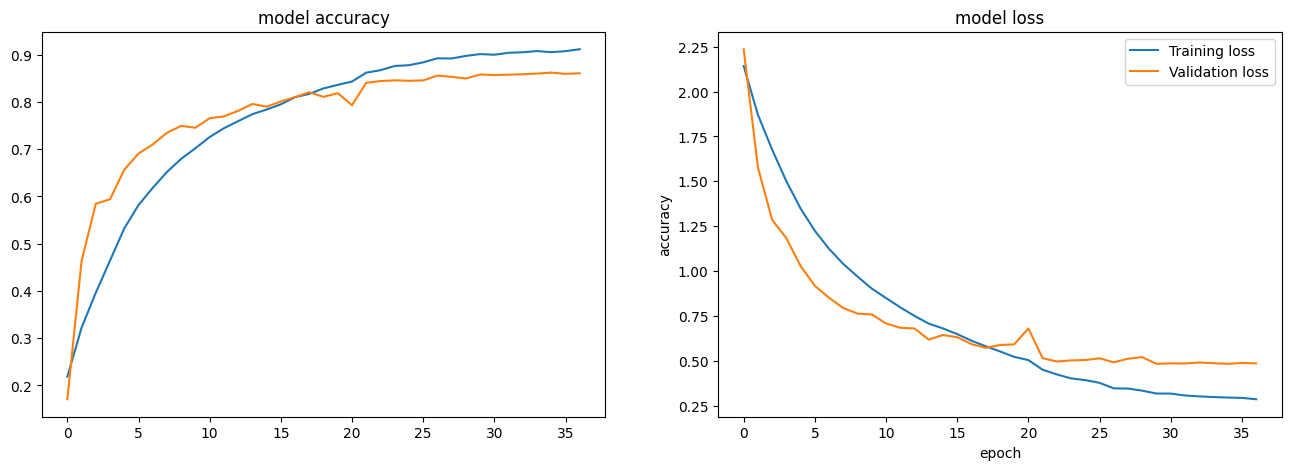

In [24]:
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

#stop training if validation accuracy stops improving
early_stop = EarlyStopping(
    monitor="val_accuracy",
    patience=10,
    min_delta=0.01,
    restore_best_weights=True
)

#reduce learning rate when validation loss plateaus
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    cooldown=0,
    min_delta=0.01,
    min_lr=5e-6
)

#training parameters
INIT_LR = 5e-4
BATCH_SIZE = 128
EPOCHS = 100


#reset previous tensorflow graph
K.clear_session()

#build the CNN model
model = make_model()

#compile model with optimizer and loss function
model.compile(
    optimizer=keras.optimizers.Adamax(learning_rate=INIT_LR),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

#train the model on the dataset
history = model.fit(
    x_train,
    y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(x_val, y_val),
    shuffle=True,
    callbacks=[early_stop, reduce_lr]
)

#plot training and validation metrics
plt.figure(figsize=(16,5))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Training accuracy")
plt.plot(history.history["val_accuracy"], label="Validation accuracy")
plt.title("model accuracy")

plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.title("model loss")

plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend(loc="best")
plt.show()

#store trained weights to avoid retraining
model.save_weights("myweights.weights.h5")

In [25]:
# load weights from file (can call without model.fit)
model.load_weights("myweights.weights.h5")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step


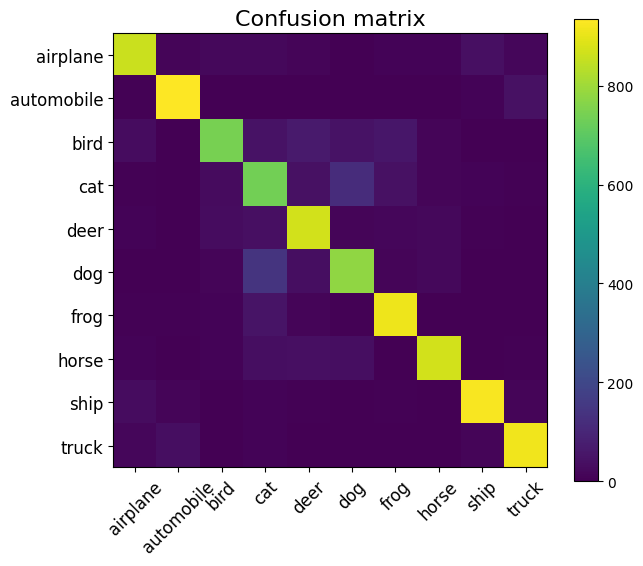

Test accuracy: 0.8543


In [26]:
# make test predictions
y_pred_test = model.predict(x_test)
y_pred_test_classes = np.argmax(y_pred_test, axis=1)
y_pred_test_max_probas = np.max(y_pred_test, axis=1)
y_test_index = [list(onehot).index(1) for onehot in y_test]

# confusion matrix and accuracy
from sklearn.metrics import confusion_matrix, accuracy_score
plt.figure(figsize=(7, 6))
plt.title('Confusion matrix', fontsize=16)
plt.imshow(confusion_matrix(y_test_index, y_pred_test_classes))
plt.xticks(np.arange(10), cifar10_classes, rotation=45, fontsize=12)
plt.yticks(np.arange(10), cifar10_classes, fontsize=12)
plt.colorbar()
plt.show()
print("Test accuracy:", accuracy_score(y_test_index, y_pred_test_classes))

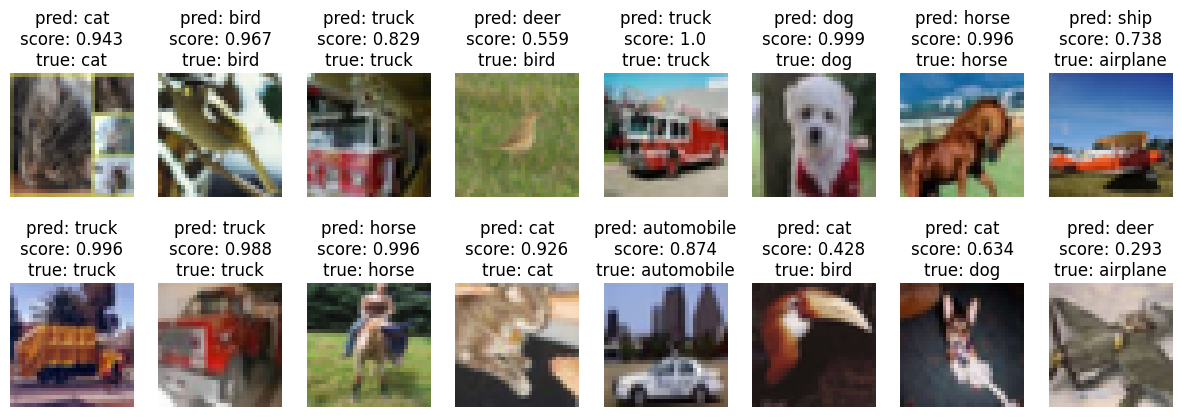

In [27]:
# inspect preditions
cols = 8
rows = 2
fig = plt.figure(figsize=(2 * cols - 1, 3 * rows - 1))
for i in range(cols):
    for j in range(rows):
        random_index = np.random.randint(0, len(y_test))
        ax = fig.add_subplot(rows, cols, i * rows + j + 1)
        ax.grid('off')
        ax.axis('off')
        ax.imshow(x_test[random_index, :])
        pred_label = cifar10_classes[y_pred_test_classes[random_index]]
        pred_proba = y_pred_test_max_probas[random_index]
        true_label = cifar10_classes[y_test_index[random_index]]
        ax.set_title("pred: {}\nscore: {:.3}\ntrue: {}".format(
               pred_label, pred_proba, true_label
        ))
plt.show()

# Some tips on how to improve:

* The ultimate quest is to create a network that has as high __accuracy__ as you can push it.

## Potential grading:
* starting at zero points
* +2 for describing your iteration path in a report below.
* +2 for building a network that gets above 20% accuracy
* +1 for beating each of these milestones on __TEST__ dataset:
    * 50% (5 total)
    * 60% (6 total)
    * 65% (7 total)
    * 70% (8 total)
    * 75% (9 total)
    * 80% (10 total)

## Bonus points
Common ways to get bonus points are:
* Get higher score, obviously.
* Anything special about your NN. For example \"A super-small/fast NN that gets 80%\" gets a bonus.
* Any detailed analysis of the results. (saliency maps, whatever)


## Tips on what can be done:

 * __Network size__
   * More neurons,
   * More layers, ([lasagne docs](http://lasagne.readthedocs.org))
   * Nonlinearities in the hidden layers
   * tanh, relu, leaky relu, etc
   * Larger networks may take more epochs to train, so don't discard your net just because it could didn't beat the baseline in 5 epochs.

 * __Convolution layers__
   * they __are a must__ unless you have any super-ideas
   * `network = lasagne.layers.Conv2DLayer(prev_layer,`
     `                       num_filters = n_neurons,`
     `                       filter_size = (filter width, filter height),`
     `                       nonlinearity = some_nonlinearity)`
   * Warning! Training convolutional networks can take long without GPU. That's okay.
     * If you are CPU-only, we still recomment to try a simple convolutional architecture
     * a perfect option is if you can set it up to run at nighttime and check it up at the morning.
     * Make reasonable layer size estimates. A 128-neuron first convolution is likely an overkill.
     * __To reduce computation__ time by a factor in exchange for some accuracy drop, try using __stride__ parameter. A stride=2 convolution should take roughly 1/4 of the default (stride=1) one.

   * Plenty other layers and architectures
     * http://lasagne.readthedocs.org/en/latest/modules/layers.html
     * batch normalization, pooling, etc


 * __Early Stopping__
   * Training for 100 epochs regardless of anything is probably a bad idea.
   * Some networks converge over 5 epochs, others - over 500.
   * Way to go: stop when validation score is 10 iterations past maximum


 * __Faster optimization__ -
   * rmsprop, nesterov_momentum, adam, adagrad and so on.
     * Converge faster and sometimes reach better optima
     * It might make sense to tweak learning rate/momentum, other learning parameters, batch size and number of epochs
   * __BatchNormalization__ (lasagne.layers.batch_norm) FTW!


 * __Regularize__ to prevent overfitting
   * Add some L2 weight norm to the loss function, theano will do the rest
     * Can be done manually or via - http://lasagne.readthedocs.org/en/latest/modules/regularization.html
   * Dropout - to prevent overfitting
     * `lasagne.layers.DropoutLayer(prev_layer, p=probability_to_zero_out)`   
     * Don't overdo it. Check if it actually makes your network better


 * __Data augmentation__ - getting 5x as large dataset for free is a great deal
   * Zoom-in+slice = move
   * Rotate+zoom(to remove black stripes)
   * any other perturbations
   * Add Noize (easiest: GaussianNoizeLayer)
   * Simple way to do that (if you have PIL/Image):
     * ```from scipy.misc import imrotate,imresize```
     * and a few slicing
   * Stay realistic. There's usually no point in flipping dogs upside down as that is not the way you usually see them.




### Training procedure, evaluation and iteration process

Once the design of a CNN is accomplished the next step is training the model.

The loss function used by the model is categorical crossentropy. This loss function is suitable for multi-class classification problems like CIFAR 10. I opted for Adamax as optimizer with an optimals not so high learning rate. Adamax was chosen because it is likely to be stable and worked well in my experiments. Throughout the training process, the model monitors its accuracy with reference to both datasets.

To make the training more efficient and avoid overfitting, I employed two callbacks. EarlyStopping is the first one which looks at the accuracy on the validation set. If and when there is no improvement after a number of epochs, it will stop the training.
 It will also automatically restore weights from the best epoch. The second callback is ReduceLROnPlateau which reduces a learning rate when the validation loss is not improving. In this manner, the network can execute more manageable updates while potentially coalescing towards a more effective solution.


While training, I also plot the accuracy and loss curves for both the training and validation set. Through model.fit(), the model is then trained on shuffled batches of training data with validation data supplied separately. The plots will show how the model learns through its training, and at what point overfitting commences.

As training proceeds, model weights are stored in a file, preventing the need for training the network every time the notebook is executed. Afterwards, use model.load_weights() to load the weights directly.

When getting predictions for test data, we find argmax on these probabilities.  We create a confusion matrix using the predicted and true labels. Next, we generate a confusion matrix for all classes. In order to analyze this we will see which classes are confused with which other classes by the model. We finally evaluate the test accuracy of our network which is our final performance measure.

It may look simple, but the display of some random test images along with their predicted label and true label is quite useful. By using it, we can have a visual representation of the working of the model. Further, we can see some examples of correct predictions and incorrect predictions concretely.

During the development of this model, I experimented with a range of CNN architectures, filter dimensions, dropout rates, as well as training configurations. This version of the network achieved greater accuracy than all the previous versions of the network neet to overfit after “some” epochs. With the addition of batch normalization and dropout layers, as well as the training callbacks I described earlier, the training became stable and the final model achieved much better performance on the unseen test set.